# Experiment — Whole-document classification with Claude

**Hypothesis:** sending all blocks in one prompt (instead of batches of 10) lets Claude see the full document structure and label ambiguous blocks more accurately.

**What this notebook does:**
1. Extract blocks from `sample2.pdf` using the existing extractor
2. Send ALL blocks to Claude in a single API call (no batching, no sliding window)
3. Parse and save the result
4. Compare block-by-block against the batched llama3.3-70b and batched claude-opus-4-8 results
5. Evaluate all three against the manual gold labels

**Pipeline code is not changed** — this is a standalone experiment.

## Setup

In [1]:
import sys, json
sys.path.insert(0, "..")

import anthropic
from pathlib import Path
from dmpbridge.extractor import extract_blocks
from dmpbridge.classifier import LABELS, SYSTEM_PROMPT
from dmpbridge import config
from evaluate import extract_gold, evaluate_sample, match, SHORT, NO_MATCH

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "figure.dpi": 120, "font.size": 11,
})

PDF_PATH    = Path("../data/pdfsamples/sample2.pdf")
GOLD_PATH   = Path("../data/manuallabeled/sample2_dmp.json")
OUT_PATH    = Path("../data/llmlabeled/sample2_claude-opus-4-8-wholedoc.json")
BATCH_PATH  = Path("../data/llmlabeled/sample2_claude-opus-4-8.json")
LLAMA_PATH  = Path("../data/llmlabeled/sample2_llama3.3-70b.json")

MODEL = "claude-opus-4-8"
client = anthropic.Anthropic(api_key=config.ANTHROPIC_API_KEY)
print("Ready.")

Ready.


## 1 — Extract blocks from sample2.pdf

In [2]:
blocks = extract_blocks(PDF_PATH)
print(f"{len(blocks)} blocks extracted from {PDF_PATH.name}")

# Preview first 5
for b in blocks[:5]:
    print(f"  [{b['page']}] bold={b['is_bold']}  {b['text'][:80]}")

171 blocks extracted from sample2.pdf
  [1] bold=True  Center for Bio-Inspired Energy Science
  [1] bold=True  1. Data sharing and preservation
  [1] bold=True  Data management plans should describe whether and how data generated in the cour
  [1] bold=True  of the proposed research will be shared and preserved. If the plan is not to sha
  [1] bold=True  preserve certain data, then the plan must explain the basis of the decision (for


## 2 — Build the whole-document prompt

All blocks go into a single prompt. No batching, no sliding context window — Claude sees the entire document at once.

In [3]:
payload = [
    {
        "id":     i,
        "text":   b["text"],
        "bold":   b["is_bold"],
        "italic": b.get("is_italic", False),
        "page":   b["page"],
    }
    for i, b in enumerate(blocks)
]

prompt = (
    f"CLASSIFY ALL BLOCKS — return a JSON array with exactly {len(payload)} entries, "
    f"one per block, in the same order:\n"
    + json.dumps(payload, ensure_ascii=False)
)

# Token estimate (rough: 1 token ≈ 4 chars)
est_tokens = len(prompt) // 4
print(f"Prompt length : {len(prompt):,} chars  (~{est_tokens:,} tokens)")
print(f"System prompt : {len(SYSTEM_PROMPT):,} chars")
print(f"Total estimate: ~{(len(prompt) + len(SYSTEM_PROMPT)) // 4:,} input tokens")

Prompt length : 25,864 chars  (~6,466 tokens)
System prompt : 3,475 chars
Total estimate: ~7,334 input tokens


## 3 — Send to Claude in one shot

In [4]:
print(f"Sending {len(payload)} blocks to {MODEL} in a single request …")

response = client.messages.create(
    model=MODEL,
    max_tokens=8192,
    system=SYSTEM_PROMPT,
    messages=[{"role": "user", "content": prompt}],
)

raw = response.content[0].text if response.content else ""
print(f"Response received — {len(raw):,} chars")
print(f"Input tokens:  {response.usage.input_tokens:,}")
print(f"Output tokens: {response.usage.output_tokens:,}")
print(f"\nFirst 300 chars of response:\n{raw[:300]}")

Sending 171 blocks to claude-opus-4-8 in a single request …


Response received — 22,970 chars
Input tokens:  10,413
Output tokens: 7,813

First 300 chars of response:
[{"id": 0, "text": "Center for Bio-Inspired Energy Science", "label": "title"},
{"id": 1, "text": "1. Data sharing and preservation", "label": "section.title"},
{"id": 2, "text": "Data management plans should describe whether and how data generated in the course", "label": "section.description"},
{"


## 4 — Parse response and save

In [5]:
# Strip markdown fences if present
raw_clean = raw.strip()
if raw_clean.startswith("```"):
    raw_clean = raw_clean.split("```", 2)[1]
    if raw_clean.startswith("json"):
        raw_clean = raw_clean[4:]
    raw_clean = raw_clean.strip()

try:
    parsed = json.loads(raw_clean)
    if isinstance(parsed, dict):
        parsed = next((v for v in parsed.values() if isinstance(v, list)), [])
except json.JSONDecodeError as e:
    print(f"JSON parse error: {e}")
    parsed = []

print(f"Parsed {len(parsed)} label entries (expected {len(blocks)})")

# Write labels back into blocks
result = [dict(b) for b in blocks]
for entry in parsed:
    idx = entry.get("id")
    lbl = entry.get("label", "answer.text")
    if idx is not None and 0 <= idx < len(result) and lbl in LABELS:
        result[idx]["label"] = lbl

# Default any unlabeled block
for b in result:
    if not b.get("label"):
        b["label"] = "answer.text"

# Save
OUT_PATH.write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Saved → {OUT_PATH}")

# Label distribution
from collections import Counter
counts = Counter(b["label"] for b in result)
print("\nLabel distribution:")
for lbl in LABELS:
    print(f"  {lbl:<25} {counts.get(lbl, 0)}")

Parsed 171 label entries (expected 171)
Saved → ..\data\llmlabeled\sample2_claude-opus-4-8-wholedoc.json

Label distribution:
  title                     1
  section.title             4
  section.description       38
  question.text             36
  answer.text               92


## 5 — Block-by-block comparison: llama vs batched claude vs whole-doc claude

In [6]:
llama   = json.loads(LLAMA_PATH.read_text(encoding="utf-8"))
batched = json.loads(BATCH_PATH.read_text(encoding="utf-8"))
wholedoc = result

gold    = extract_gold(GOLD_PATH)

rows = []
for i, (lb, cb, wb) in enumerate(zip(llama, batched, wholedoc)):
    true_lbl = match(lb["text"], gold)
    rows.append({
        "id":          i,
        "text":        lb["text"][:60],
        "gold":        true_lbl or "?",
        "llama70":     lb["label"],
        "claude_batch": cb["label"],
        "claude_whole": wb["label"],
    })

df = pd.DataFrame(rows)

# Show only blocks where at least one model differs from gold
has_gold = df["gold"] != "?"
any_wrong = (
    (df["llama70"] != df["gold"]) |
    (df["claude_batch"] != df["gold"]) |
    (df["claude_whole"] != df["gold"])
)
errors_df = df[has_gold & any_wrong].reset_index(drop=True)
print(f"Blocks where at least one model is wrong: {len(errors_df)} / {has_gold.sum()}")
pd.set_option("display.max_colwidth", 62)
display(errors_df)

Blocks where at least one model is wrong: 35 / 171


,id,text,gold,llama70,claude_batch,claude_whole
0,9,"Roles & Responsibilities. For the proposed research, Directo",answer.text,answer.text,answer.text,question.text
1,15,the course of the proposed research and which of these are c,question.text,section.description,question.text,question.text
2,16,necessary to Validate the research findings.,question.text,section.description,question.text,question.text
3,27,"applicable, a description of documentation plans, annotation",question.text,section.description,question.text,question.text
4,28,"the selection of appropriate standards. (Existing, accepted",question.text,section.description,question.text,question.text
5,29,possible. Where community standards are missing or inadequat,question.text,section.description,question.text,question.text
6,30,"strategies that facilitate data sharing, and should advise t",question.text,section.description,question.text,question.text
7,31,develop or generalize standards.),question.text,section.description,question.text,question.text
8,47,Data Sharing and Data Preservation. A description of the pla,question.text,section.title,question.text,question.text
9,48,"This should include, where appropriate:",question.text,section.description,section.description,question.text


## 6 — Accuracy comparison

In [7]:
def score(pred_col):
    sub = df[df["gold"] != "?"]
    correct = (sub[pred_col] == sub["gold"]).sum()
    total   = len(sub)
    return correct, total

models = {
    "llama3.3-70b":        "llama70",
    "claude-opus-4-8 (batched)": "claude_batch",
    "claude-opus-4-8 (whole-doc)": "claude_whole",
}

print(f"{'Model':<34}  {'Correct':>7}  {'Total':>5}  {'Accuracy':>8}")
print("-" * 60)
accs = {}
for name, col in models.items():
    c, t = score(col)
    acc  = c / t * 100
    accs[name] = acc
    print(f"{name:<34}  {c:>7}  {t:>5}  {acc:>7.1f}%")

Model                               Correct  Total  Accuracy
------------------------------------------------------------
llama3.3-70b                            156    171     91.2%
claude-opus-4-8 (batched)               149    171     87.1%
claude-opus-4-8 (whole-doc)             166    171     97.1%


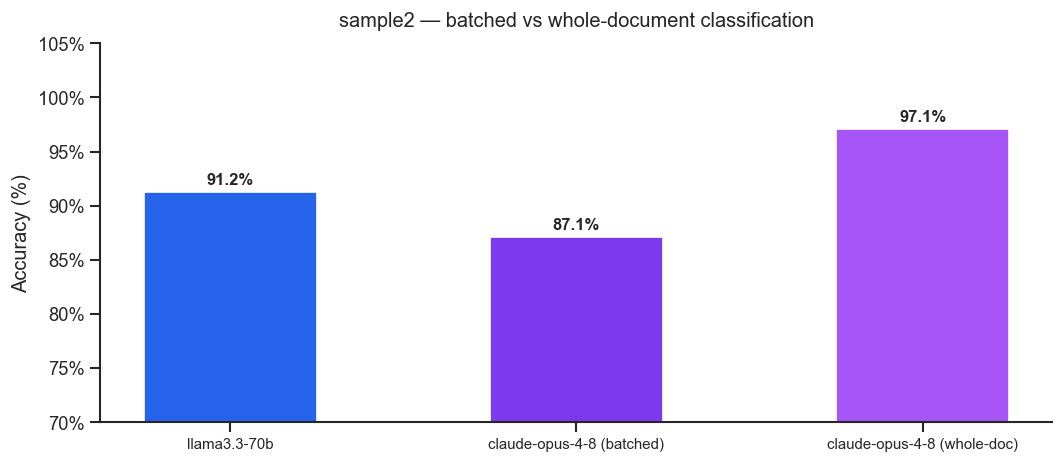

In [8]:
# Accuracy bar chart
colors = ["#2563eb", "#7c3aed", "#a855f7"]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(list(accs.keys()), list(accs.values()),
              color=colors, width=0.5, edgecolor="white")
for bar, v in zip(bars, accs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(70, 105)
ax.set_ylabel("Accuracy (%)")
ax.set_title("sample2 — batched vs whole-document classification", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.tick_params(axis="x", labelsize=9)
sns.despine(); plt.tight_layout(); plt.show()

## 7 — Where did whole-doc Claude improve over batched Claude?

Blocks where `claude_whole` is correct but `claude_batch` was wrong — these are the gains from full-document context.

In [9]:
sub = df[df["gold"] != "?"].copy()

gained = sub[(sub["claude_whole"] == sub["gold"]) & (sub["claude_batch"] != sub["gold"])]
lost   = sub[(sub["claude_whole"] != sub["gold"]) & (sub["claude_batch"] == sub["gold"])]

print(f"Whole-doc GAINED over batched: {len(gained)} blocks")
if not gained.empty:
    display(gained[["id","gold","claude_batch","claude_whole","text"]].reset_index(drop=True))

print(f"\nWhole-doc LOST vs batched: {len(lost)} blocks")
if not lost.empty:
    display(lost[["id","gold","claude_batch","claude_whole","text"]].reset_index(drop=True))

Whole-doc GAINED over batched: 19 blocks


,id,gold,claude_batch,claude_whole,text
0,48,question.text,section.description,question.text,"This should include, where appropriate:"
1,49,question.text,section.description,question.text,the anticipated means for sharing and rationale for any rest
2,50,question.text,section.description,question.text,and under what conditions;
3,51,question.text,section.description,question.text,a timeline for sharing and preservation that addresses both
4,52,question.text,section.description,question.text,will be available and any anticipated delay to data access a
5,53,question.text,section.description,question.text,"any special requirements for data sharing, for example, prop"
6,54,question.text,section.description,question.text,"or interpret data, applicable policies, provisions, and lice"
7,55,question.text,section.description,question.text,"for the production of derivatives, including guidance for ho"
8,56,question.text,section.description,question.text,cited;
9,57,question.text,section.description,question.text,"any resources and capabilities (equipment, connections, syst"



Whole-doc LOST vs batched: 2 blocks


,id,gold,claude_batch,claude_whole,text
0,9,answer.text,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Directo"
1,153,answer.text,answer.text,question.text,"Data Volume. Generally, the volume of data generated by CBES"


## 8 — Where does whole-doc Claude beat llama3.3-70b?

Blocks where whole-doc Claude is correct but llama was wrong.

In [10]:
beats_llama = sub[(sub["claude_whole"] == sub["gold"]) & (sub["llama70"] != sub["gold"])]
loses_llama = sub[(sub["claude_whole"] != sub["gold"]) & (sub["llama70"] == sub["gold"])]

print(f"Whole-doc Claude BEATS llama3.3-70b: {len(beats_llama)} blocks")
if not beats_llama.empty:
    display(beats_llama[["id","gold","llama70","claude_whole","text"]].reset_index(drop=True))

print(f"\nWhole-doc Claude LOSES to llama3.3-70b: {len(loses_llama)} blocks")
if not loses_llama.empty:
    display(loses_llama[["id","gold","llama70","claude_whole","text"]].reset_index(drop=True))

Whole-doc Claude BEATS llama3.3-70b: 12 blocks


,id,gold,llama70,claude_whole,text
0,15,question.text,section.description,question.text,the course of the proposed research and which of these are c
1,16,question.text,section.description,question.text,necessary to Validate the research findings.
2,27,question.text,section.description,question.text,"applicable, a description of documentation plans, annotation"
3,28,question.text,section.description,question.text,"the selection of appropriate standards. (Existing, accepted"
4,29,question.text,section.description,question.text,possible. Where community standards are missing or inadequat
5,30,question.text,section.description,question.text,"strategies that facilitate data sharing, and should advise t"
6,31,question.text,section.description,question.text,develop or generalize standards.)
7,47,question.text,section.title,question.text,Data Sharing and Data Preservation. A description of the pla
8,48,question.text,section.description,question.text,"This should include, where appropriate:"
9,92,question.text,section.description,question.text,"including, for example, the potential impact of the data wit"



Whole-doc Claude LOSES to llama3.3-70b: 2 blocks


,id,gold,llama70,claude_whole,text
0,9,answer.text,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Directo"
1,145,answer.text,answer.text,question.text,Data Repositories. Senior investigators typically archive re
